In [94]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
from gymnasium import spaces

import collections

from dm_control import mujoco, viewer, suite
from dm_control.rl import control
from dm_control.suite import base, common
from dm_control.suite.utils import randomizers
from dm_control.utils import rewards
from dm_control.utils import io as resources
from dm_env import specs
import numpy as np
import os

from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import clear_output

import random

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [95]:
MIN_NUM_ANCHORS = 1
MAX_NUM_ANCHORS = 1
EPISODE_LENGTH = 300
NUM_RANDOM_STEPS = 100
STATE_SCALE = 100

# Reward Generator:

In [96]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=128):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            # nn.Linear(512, 512),
            # nn.LayerNorm(512),
            # nn.Mish(),
            nn.Linear(512, 1),
        )



    def get_transformer_encoding(self, states, pad_mask):  
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        state_emb = self.state_embed(states)        

        w_pre = self.encoder_transformer(state_emb, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

In [97]:
# fre_network = FRENetwork(obs_len=2)
# fre_network.load_state_dict(torch.load('models/reward_generator.pth'))
# statistics = torch.load('models/reward_generator_mean_std.pth')
# emperical_mean = statistics['emperical_mean']
# emperical_std = statistics['emperical_std']

In [98]:
class RewardGenerator:
    def __init__(self, obs_dim, fre_network: FRENetwork, min_num_anchors, max_num_anchors, from_buffer, max_buffer_size=1e6):
        self.obs_dim = obs_dim
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)
        
        self.emperical_mean = torch.zeros((128,), dtype=torch.float32, device=device)
        self.emperical_std  = torch.ones((128,), dtype=torch.float32, device=device)    
    
        self.from_buffer = from_buffer
        self.new_states_buffer = None
        self.states_buffer = None
        self.max_buffer_size = max_buffer_size
        
        self.std = 1
        
        self.len_params = 128
        
        self.min_num_anchors = min_num_anchors
        self.max_num_anchors = max_num_anchors
        
    def update_states_buffer(self, new_states):

        # num_trajectories, len_trajectory, obs_dim = new_states.shape
        # for i in range(num_trajectories):
        #     if len(self.states_buffer) < self.max_buffer_size:
        #         self.states_buffer.append(new_states[i].cpu())
        #     else:
        #         j = random.randint(0, self.max_buffer_size-1)
        #         self.states_buffer[j] = new_states[i].cpu()
        
        if self.states_buffer is None:
            self.states_buffer = new_states
        else:
            self.states_buffer = torch.concatenate((self.states_buffer, new_states), dim=1)
        
    
    def update_new_states_buffer(self, new_states):
        if self.new_states_buffer is None:
            self.new_states_buffer = new_states
        else:
            self.new_states_buffer = torch.concatenate((self.new_states_buffer, new_states), dim=1)

    
    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    
    
    
    def get_training_data(self, batch_size, min_num_anchors, max_num_anchors, num_states, from_new_states=False):
        assert min_num_anchors <= max_num_anchors <= num_states

        
        all_states = torch.zeros((batch_size, num_states, 2), dtype=torch.float32)
        anchors = torch.zeros((batch_size, max_num_anchors, 2), dtype=torch.float32)
        
        buffer = self.new_states_buffer if from_new_states else self.states_buffer
        assert buffer is not None
        
        
        # Get anchors:
        trajectories_idx = torch.randint(0, buffer.shape[0], (batch_size, 1)).repeat(1, max_num_anchors).reshape(-1)
        states_idx       = torch.randint(0, buffer.shape[1], (max_num_anchors*batch_size,))
        anchors = buffer[trajectories_idx, states_idx]
        anchors = anchors.reshape(batch_size, max_num_anchors, 2)
        all_states[:, :max_num_anchors, :] = anchors
                    
            
        # Get non anchors
        num_non_anchors = num_states - max_num_anchors
        trajectories_idx = torch.randint(0, buffer.shape[0], (num_non_anchors*batch_size,))
        states_idx       = torch.randint(0, buffer.shape[1], (num_non_anchors*batch_size,))
        non_anchors = buffer[trajectories_idx, states_idx]
        non_anchors = non_anchors.reshape(batch_size, num_non_anchors, 2)
        all_states[:, max_num_anchors:, :] = non_anchors
            
            

        rewards = torch.zeros((batch_size, num_states, 1), dtype=torch.float32)
        pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)
        
        # Generate random number of anchors for each batch element
        num_anchors = torch.randint(min_num_anchors, max_num_anchors + 1, (batch_size,))
        
        reward_indices = torch.arange(num_states).unsqueeze(0)
        reward_mask = reward_indices < num_anchors.unsqueeze(1)
        rewards[reward_mask] = 1
        
        pad_mask_indices = torch.arange(max_num_anchors).unsqueeze(0)
        pad_mask = pad_mask_indices < num_anchors.unsqueeze(1)
        pad_mask = ~pad_mask
        

        return (anchors, pad_mask), (all_states, rewards)
    
    
    def get_training_data_(self, batch_size, min_num_anchors, max_num_anchors, num_states, from_new_states=False):
        assert min_num_anchors <= max_num_anchors <= num_states
        assert self.states_buffer is not None
        
        # all_states = []
        # trajectories_idx = np.random.randint(0, len(self.states_buffer), size=(num_states*batch_size,))
        # for i in trajectories_idx:
        #     j = random.randint(0, len(self.states_buffer[i])-1)
        #     state = self.states_buffer[i][j]
        #     all_states.append(state)
        
        anchors = torch.rand((batch_size, max_num_anchors, 2)) * 0.6 - 0.3
        non_anchors = torch.rand((batch_size, num_states - max_num_anchors, 2)) * 0.6 - 0.3
        all_states = torch.concatenate((anchors, non_anchors), dim=1)
            
        # all_states = torch.stack(all_states).reshape(batch_size, num_states, -1)
        # anchors = all_states[:, :max_num_anchors]
        
        rewards = torch.zeros((batch_size, num_states, 1), dtype=torch.float32)
        rewards[:, :max_num_anchors] = 1
        rewards[:, max_num_anchors:] = 0
        
        pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)
        for i in range(batch_size):
            num_anchors = random.randint(min_num_anchors, max_num_anchors)
            anchors   [i, num_anchors:max_num_anchors] = 0
            all_states[i, num_anchors:max_num_anchors] = 0
            rewards   [i, num_anchors:max_num_anchors] = 0
            pad_mask  [i, :num_anchors] = False
            

        return (anchors, pad_mask), (all_states, rewards)
        
        
        
    
        
    def train_step_VAE(self, batch_size, min_num_anchors, max_num_anchors, num_states, non_anchor_coef=0.5, from_new_states=False):
        self.fre_network.train()
        
        (anchors, pad_mask), (all_states, rewards) = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            num_states=num_states,
            from_new_states=from_new_states
        )
        anchors = anchors.to(device)
        pad_mask = pad_mask.to(device)
        all_states = all_states.to(device)
        rewards = rewards.to(device)
        
        # print(anchors)
        # print(anchors.sum())
        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, pad_mask=pad_mask)
        
        
        # Calculate the loss:
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = w_mean
        rewards_pred = self.fre_network.get_reward_pred(w, all_states)
        # rewards_pred = torch.clip(rewards_pred, 0, 1)
        
        is_anchor = (rewards == 1)
        reward_pred_loss = ((rewards_pred[ is_anchor] - 1)**2).mean() + ((rewards_pred[~is_anchor] - 0)**2).mean() * non_anchor_coef
                        
        
        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = reward_pred_loss + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'reward_pred_loss': reward_pred_loss.item(),
            'kl_loss': kl_loss.item(),
        }
        
        
    def visualize(self, num_anchors, from_new_states=False):
        self.fre_network.eval()
        
        min_num_anchors, max_num_anchors = num_anchors, num_anchors
        (anchors, pad_mask), (all_states, rewards) = self.get_training_data(
            batch_size=1, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            num_states=10000,
            from_new_states=from_new_states
        )
        anchors = anchors.to(device)
        pad_mask = pad_mask.to(device)
        all_states = all_states.to(device)
        rewards = rewards.to(device)


        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, pad_mask)   


        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = torch.normal(0, 1, (1, 128), device=device) * 0.5

        rewards_pred = self.fre_network.get_reward_pred(w, all_states)


        plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=rewards_pred.detach().cpu(), vmin=0, vmax=1)
        plt.scatter(anchors[0, :, 0].cpu(), anchors[0, :, 1].cpu(), c='red')
        
        
    def estimate_mean_std(self, steps=10000, num_anchors=None):
        # assert len(self.states_buffer) > 0
        
        self.fre_network.eval()
        
        all_means, all_vars = [], []
        # for  _ in tqdm(range(steps), desc='Estimate_mean_std'):
        for  _ in range(steps):
            (anchors, pad_mask), (_, _) = self.get_training_data(
                batch_size=1, 
                min_num_anchors=self.min_num_anchors if (num_anchors is None) else num_anchors, 
                max_num_anchors=self.max_num_anchors if (num_anchors is None) else num_anchors,
                num_states=10
            )
            anchors = anchors.to(device)
            pad_mask = pad_mask.to(device)

            with torch.no_grad():
                w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, pad_mask)   
                var = torch.exp(2*w_log_std)
            all_means.append(w_mean[0].cpu())
            all_vars.append(var[0].cpu())

        emperical_mean = torch.stack(all_means).mean(dim=0).to(device)

        sigma_hat = (torch.stack(all_vars).to(device) + torch.stack(all_means).to(device)**2).mean(dim=0) - emperical_mean**2
        emperical_std = sigma_hat ** 0.5
        
        self.emperical_std  = emperical_std
        self.emperical_mean = emperical_mean
        
        return emperical_mean, emperical_std
    
    
    def get_z_from_prior(self, batch_size: int):
        eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        z = self.emperical_mean + eps * self.emperical_std
        return z, {}
    
    
    def get_z_from_random_anchors(self, batch_size: int, min_num_anchors:int, max_num_anchors:int):
        assert self.new_states_buffer is not None
        self.fre_network.eval()
        
        (anchors, pad_mask), (_, _) = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
            num_states=max_num_anchors, # not important, we only need the anchors
            from_new_states=True
        )
        anchors = anchors.to(device)
        pad_mask = pad_mask.to(device)

        eval_z, _ = self.get_z_from_anchors(anchors, pad_mask)
        return eval_z, {'anchors': anchors.cpu()}
        
            
    def get_z_from_anchors(self, anchors: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.eval()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, pad_mask) 
        
        eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        z = w_mean + eps * torch.exp(w_log_std)
        return z, {'anchors': anchors.cpu()}

        


In [99]:
# fre_network = FRENetwork(obs_len=2)
# # fre_network.load_state_dict(torch.load('models/reward_generator.pth'))

# reward_generator = RewardGenerator(
#     obs_dim=2,
#     fre_network=fre_network,
#     from_buffer=True,
#     max_buffer_size=10000,
#     min_num_anchors=MIN_NUM_ANCHORS,
#     max_num_anchors=MAX_NUM_ANCHORS,
# )


# # print('Getting new states...')
# # trajectory, random_states = get_new_states(env, model, reward_generator, num_policy_steps=EPISODE_LENGTH, num_random_steps=50)
# # reward_generator.update_new_states_buffer(random_states[..., :2])
# # reward_generator.update_states_buffer    (random_states[..., :2])
# # reward_generator.update_states_buffer    (trajectory['states'][..., :2].reshape(-1, EPISODE_LENGTH, 2))
# # print(len(reward_generator.states_buffer))

# x = torch.rand((100, 50, 2)) * 0.6 - 0.3
# reward_generator.update_new_states_buffer(x)
# reward_generator.update_states_buffer    (x)

In [100]:
# for _ in tqdm(range(1000)):
#     # (anchors, pad_mask), (all_states, rewards) = reward_generator.get_training_data(
#     #     batch_size=256, 
#     #     min_num_anchors=8, 
#     #     max_num_anchors=8,
#     #     num_states=16,
#     #     from_new_states=False
#     # )
    
#     reward_generator.train_step_VAE(
#         batch_size=256,
#         min_num_anchors=8, 
#         max_num_anchors=8,
#         num_states=16,
#     )
    
#     # trajectories_idx = torch.randint(0, reward_generator.states_buffer.shape[0], (8*256,))
#     # states_idx =       torch.randint(0, reward_generator.states_buffer.shape[1], (8*256,))
#     # non_anchors = reward_generator.states_buffer[trajectories_idx, states_idx]
#     # non_anchors = non_anchors.reshape(256, 8, 2)

In [101]:
# losses, pred_losses = [], []

# for i in tqdm(range(100000)):
    
#     loss_dict = reward_generator.train_step_VAE(
#         batch_size=256,
#         min_num_anchors=1,
#         max_num_anchors=10,
#         num_states=16
#     )
#     losses.append(loss_dict['loss'])
#     pred_losses.append(loss_dict['kl_loss'])
    
#     if i % 1000 == 0:
#         clear_output(True)
#         fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        
#         axs[0].plot(losses)
#         axs[0].set_ylim([0, 0.5])
        
#         axs[1].plot(pred_losses)
#         axs[1].set_ylim([0, 1])
        
#         plt.show()
        
#     # break

# Jax ENV:

In [102]:
import jax
import jax.numpy as jnp
from brax import base
from brax.envs.base import PipelineEnv, State
from brax.io import mjcf
from etils import epath
import jax
from jax import numpy as jp


class PointMaze(PipelineEnv):

    def __init__(self, path):

        backend='mjx' #'generalized'
        kwargs={}
        
        # self.path = 'mazes/point_mass_maze_empty.xml'
        # self.path = 'mazes/point_mass_maze_hardest.xml'
        self.path = path
        sys = mjcf.load(self.path)
        
        n_frames = 1
        kwargs['n_frames'] = kwargs.get('n_frames', n_frames)
        super().__init__(sys=sys, backend=backend, **kwargs)
        
        # path = epath.resource_path('brax') / 'envs/assets/half_cheetah.xml'
        
        
    def reset(self, rng: jax.Array) -> State:
        """Resets the environment to an initial state."""
        rng, rng1, rng2 = jax.random.split(rng, 3)

        _reset_noise_scale = 0.001

        low, hi = -_reset_noise_scale, _reset_noise_scale
        # qpos = self.sys.init_q + jax.random.uniform(
        #     rng1, (self.sys.q_size(),), minval=low, maxval=hi
        # )
        # qpos = self.sys.init_q
        qpos = jnp.array([0.025, 0.])
        # print(self.sys.init_q, qpos)
        qvel = hi * jax.random.normal(rng2, (self.sys.qd_size(),))
        
        pipeline_state = self.pipeline_init(qpos, qvel)

        
        obs = self._get_obs(pipeline_state)
        reward, done, zero = jp.zeros(3)
        metrics = {
            'x_position': zero,
            'y_position': zero,
        }
        return State(pipeline_state, obs, reward, done, metrics)
    
    def step(self, state: State, action: jax.Array) -> State:
        pipeline_state0 = state.pipeline_state
        assert pipeline_state0 is not None
        pipeline_state = self.pipeline_step(pipeline_state0, action)

        obs = self._get_obs(pipeline_state)
        reward = 0

        return state.replace(pipeline_state=pipeline_state, obs=obs, reward=reward)
    
    def _get_obs(self, pipeline_state):
        return jnp.concatenate((pipeline_state.qpos, pipeline_state.qvel), axis=-1) * STATE_SCALE

In [103]:
from brax.io import torch as io_torch
import random

class TorchWrapper:
    def __init__(self, env, num_envs):
        
        self.env = env
        self.num_envs = num_envs
        self.state_dim = env.observation_size
        self.action_dim = env.action_size
        
        
        self.reset_fn = jax.jit(jax.vmap(env.reset))
        self.step_fn = jax.jit(jax.vmap(env.step))
        
        # self.reset_fn = jax.vmap(env.reset)
        # self.step_fn = jax.vmap(env.step)
        
    
    def reset(self, seed=None):
        
        random_key = jax.random.PRNGKey(random.randint(0, 99999999))
        keys = jax.random.split(random_key, num=self.num_envs)
        # random_key, subkey = jax.random.split(random_key)
        if seed == 1:
            keys = jax.random.PRNGKey(random.randint(0, 99999999))
        state = self.reset_fn(keys)
        self.state = state
        return io_torch.jax_to_torch(state.obs), {}
    
    def step(self, action: torch.Tensor):
        
        action = io_torch.torch_to_jax(action)
        next_state = self.step_fn(self.state, action)
        observation, reward, done = next_state.obs, next_state.reward, next_state.done
        observation = io_torch.jax_to_torch(observation)
        reward = io_torch.jax_to_torch(reward)
        done = io_torch.jax_to_torch(done)
        
        self.state = next_state
        truncated = torch.full_like(done, fill_value=False)
        return observation, reward, done, truncated, {}
        

In [104]:
# base_env = PointMaze()

# env = TorchWrapper(base_env, num_envs=128)

# state, _ = env.reset()
# action = torch.zeros((128, 2)).float()
# next_state, reward, done, truncated, info = env.step(action)

# PPO:

In [105]:
def compute_gae_parallel(dones, rewards, values, next_values, gamma=0.99, lambda_=0.95):
    assert (
        dones.shape == rewards.shape == values.shape == next_values.shape
    ), "All inputs must have the same shape (num_envs, sequence_length)."

    num_envs, seq_len = dones.shape
    advantages = torch.zeros_like(rewards, dtype=torch.float32)
    returns = torch.zeros_like(rewards, dtype=torch.float32)
    last_advantage = torch.zeros(num_envs, dtype=torch.float32)
    last_return = torch.zeros(num_envs, dtype=torch.float32)

    for t in reversed(range(seq_len)):
        mask = 1.0 - dones[:, t]
        last_value = next_values[:, t] * mask
        last_advantage = last_advantage * mask
        last_return = last_return * mask

        delta = rewards[:, t] + gamma * last_value - values[:, t]
        last_advantage = delta + gamma * lambda_ * last_advantage
        last_return = rewards[:, t] + gamma * last_return

        advantages[:, t] = last_advantage
        returns[:, t] = last_return

    return advantages, returns


def post_process(action):
    # return torch.tanh(action)
    return torch.clip(action, -1, 1)


def collect_trajectories(env, z, model, n_steps, reward_generator: RewardGenerator, num_random_steps=0):

    # state_dim, action_dim = env.single_observation_space.shape[0], env.single_action_space.shape[0]
    state_dim, action_dim = env.state_dim, env.action_dim
    
    states = torch.zeros((env.num_envs, n_steps, state_dim), dtype=torch.float32)
    zs = torch.zeros((env.num_envs, n_steps, reward_generator.len_params), dtype=torch.float32)
    actions = torch.zeros((env.num_envs, n_steps, action_dim), dtype=torch.float32)
    rewards = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    log_ps = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    state_values = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)
    dones = torch.zeros((env.num_envs, n_steps), dtype=torch.float32)

    random_states = torch.zeros((env.num_envs, num_random_steps, state_dim), dtype=torch.float32)
    
    state, _ = env.reset()
    

    total_reward = 0
    step_count = 0
    
    # Just to get the dist:
    state = state.to(device)
    with torch.no_grad():
        _, _, _, dist, _ = model(state, z)
    
    
    for s in range(n_steps + num_random_steps):
        # state = torch.tensor(state).to(device)
        state = state.to(device)
        
        if s < n_steps:
            with torch.no_grad():
                action, log_p, state_value, dist, entropy = model(state, z)
                
            next_state, reward, terminated, truncated, _ = env.step(post_process(action).cpu())
            done = terminated * truncated

            # print(state[..., :2].shape, z.shape)
            gm_reward = reward_generator.get_reward(state[..., :2], z)
            # gm_reward = torch.zeros((env.num_envs,))
            
            states[:, s] = state
            zs[:, s] = z.squeeze(-1)
            actions[:, s] = action
            rewards[:, s] = gm_reward.reshape(-1)
            log_ps[:, s] = log_p
            state_values[:, s] = state_value.reshape(-1)
            dones[:, s] = done
        
        
        else: # Increase the standard deviation:
            # print(s)
            dist.scale = torch.exp(torch.full_like(dist.scale, fill_value=model.action_std**2))
            random_action = dist.sample()
            action = random_action
            next_state, reward, terminated, truncated, _ = env.step(post_process(action).cpu())
            
            random_states[:, s - n_steps] = state
            
        
        
        state = next_state
            
        

    
    critic_x = torch.concatenate((next_state, z.cpu()), dim=-1).to(device)
    next_value = model.critic(critic_x).cpu()
    next_state_values = torch.concatenate((state_values[:, 1:], next_value), dim=-1)
    
    advantages, returns = compute_gae_parallel(dones, rewards, state_values, next_state_values)
        
            
    trajectories = {
        # "descriptors": condition_descriptor.unsqueeze(1).repeat(1, n_steps, 1).reshape(-1, BEHAVIOR_DIM**2),
        "states" :  states.reshape(-1, state_dim).detach().cpu(),
        "zs" :  zs.reshape(-1, reward_generator.len_params).detach().cpu(),
        "actions" : actions.reshape(-1, action_dim).detach().cpu(),
        "rewards" : rewards.reshape(-1).detach().cpu(),
        "dones" : dones.reshape(-1).detach().cpu(),
        "log_ps" : log_ps.reshape(-1).detach().cpu(),
        "state_values": state_values.reshape(-1).detach().cpu(),
        "next_state_values": next_state_values.reshape(-1).detach().cpu(),
        "returns" : returns.reshape(-1).detach().cpu(),
        "advantages" : advantages.reshape(-1).detach().cpu(),
    }
    
    return trajectories, random_states


# trajectories = collect_trajectories(env, model, n_steps=128)

# for key in trajectories:
#     print(key, trajectories[key].shape)

def shufffle_trajectory(trajectories):
    length = trajectories['states'].shape[0]
    permutation = torch.randperm(length)

    shuffled_trajectories = {key: tensor[permutation] for key, tensor in trajectories.items()}
    return shuffled_trajectories

# shuffled_trajectories = shufffle_trajectory(trajectories)
# z, _ = reward_generator.sample(num_envs)
# trajectory, random_states = collect_trajectories(env, z, model, n_steps=100, reward_generator=reward_generator)

In [106]:
def ppo_optimization(trajectories, model, optimizer, epochs, batch_size):
    
    model.train()
    
    traj_states = trajectories["states"]
    traj_z = trajectories["zs"]
    traj_actions = trajectories["actions"]
    traj_log_ps = trajectories["log_ps"]
    traj_returns = trajectories["returns"]  
    traj_advantages = trajectories["advantages"]


    len_trajectory = traj_states.shape[0]

    for epoch in range(1, epochs+1):
        for i in range(len_trajectory // batch_size):
            state = traj_states[batch_size*i:batch_size*(i+1)].to(device)
            z = traj_z[batch_size*i:batch_size*(i+1)].to(device)
            action = traj_actions[batch_size*i:batch_size*(i+1)].to(device)
            log_p = traj_log_ps[batch_size*i:batch_size*(i+1)].to(device)
            return_ = traj_returns[batch_size*i:batch_size*(i+1)].to(device)
            advantage = traj_advantages[batch_size*i:batch_size*(i+1)].to(device)
            
            new_action, new_log_p, new_state_value, dist, entropy = model(state, z, action)
            assert(new_action == action).all()
            
            
            advantage = (advantage - advantage.mean()) / (advantage.std() + 1e-8)
                    
            new_log_p, log_p, advantage = new_log_p.reshape(-1), log_p.reshape(-1), advantage.reshape(-1)
            
            
            ratio = torch.exp(new_log_p - log_p.detach())
            surr1 = ratio * advantage
            surr2 = torch.clamp(ratio, 1-0.2, 1+0.2) * advantage
            policy_loss = - torch.min(surr1, surr2).mean()
            
            # print(ratio)
            
            # print(advantage[:10])
            # print(ratio[:10])
            # print(value_loss)
            # print(policy_loss)
            
            
            return_, new_state_value = return_.reshape(-1), new_state_value.reshape(-1)

            value_loss = ((return_ - new_state_value)**2).mean()

            loss = policy_loss - 2e-7*entropy.mean() + 0.5*value_loss

            # print(return_[:5])
            # print(new_state_value[:5])
            
            
            optimizer.zero_grad()
            loss.backward()
            clip_factor = torch.nn.utils.clip_grad_norm_(model.parameters(), 0.5)
            optimizer.step()
            
    return entropy.mean().item()
            
# ppo_optimization(trajectories, model, optimizer, epochs=1, batch_size=5)
# ppo_optimization(shuffled_trajectory, model, optimizer, epochs=5, batch_size=256)

In [107]:
class ActorCriticContinuous(nn.Module):
    def __init__(self, state_dim, z_dim, action_dim, actor_hidden_layers, critic_hidden_layers, action_std=0.5, use_layernorm=False):
        super(ActorCriticContinuous, self).__init__()
        
        self.state_dim = state_dim
        self.z_dim = z_dim
        self.action_dim = action_dim
        
        
        # Define actor network
        actor_layers = []
        input_dim = state_dim + z_dim
        for hidden_dim in actor_hidden_layers:
            actor_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_layernorm:
                actor_layers.append(nn.LayerNorm(hidden_dim))
            actor_layers.append(nn.ReLU())
            input_dim = hidden_dim
        actor_layers.append(nn.Linear(input_dim, action_dim))
        self.actor = nn.Sequential(*actor_layers)
        
        # Define critic network
        critic_layers = []
        input_dim = state_dim + z_dim
        for hidden_dim in critic_hidden_layers:
            critic_layers.append(nn.Linear(input_dim, hidden_dim))
            if use_layernorm:
                actor_layers.append(nn.LayerNorm(hidden_dim))
            critic_layers.append(nn.ReLU())
            input_dim = hidden_dim
        critic_layers.append(nn.Linear(input_dim, 1))
        self.critic = nn.Sequential(*critic_layers)
        
        self.action_std = action_std
        self.action_var = nn.Parameter(torch.full((action_dim,), action_std**2, requires_grad=True))


    def forward(self, obs, fre_idx, action=None):
        x = torch.concat((obs, fre_idx), dim=-1)
        action_mean = self.actor(x)
        cov_matrix = torch.exp(self.action_var)
        dist = torch.distributions.Normal(loc=action_mean, scale=cov_matrix)
        
        if action is None:
            action = dist.sample()
            
        log_p = dist.log_prob(action).sum(dim=-1)
        
        value = self.critic(x)
        
        return action, log_p, value, dist, dist.entropy()

In [108]:
def add_largest_maze_walls(ax):
    

    maze_optim = [
        (1, 1, 1, 2),    
        (0, 4, 2, 1),
        (3, 1, 1, 4),
        (5, 0, 1, 1),
        (4, 2, 3, 1),
        (1, 6, 3, 1),
        (4, 4, 2, 1),
        (5, 6, 2, 1),
        (1, 8, 1, 1),
        (3, 7, 1, 2),
        (5, 8, 1, 2)
    ]

    block_size = 0.025 * STATE_SCALE

    height, width = 7, 10
    torso_x, torso_y = (width - 1)*block_size, (height - 1)*block_size
    # torso_x, torso_y = 0, 0

    # Get current axes
    # ax = plt.gca()

    rects = []
    for i in range(len(maze_optim)):
        (y, x, w, h) = maze_optim[i]
            
        x = x * block_size * 2 - torso_x + (h - 1) * block_size - h * block_size
        y = y * block_size * 2 - torso_y + (w - 1) * block_size - w * block_size
        h, w = h * block_size * 2, w * block_size * 2
        
        rect = patches.Rectangle((x, y), h, w, linewidth=2, edgecolor='gray', facecolor='gray')

        ax.add_patch(rect)
        
    rect = patches.Rectangle(
        (-torso_x - block_size, -torso_y - block_size), 
        block_size*width*2, block_size*height*2, 
        linewidth=2, edgecolor='black', facecolor='none'
    )
    ax.add_patch(rect)


    # plt.axis('equal')
    # plt.xlim([-torso_x - block_size, -torso_x - block_size + block_size*width*2])
    # plt.ylim([-torso_y - block_size, -torso_y - block_size + block_size*height*2])
    # plt.show()

In [109]:
# path = 'mazes/point_mass_maze_empty.xml'
path = 'mazes/point_mass_maze_hardest.xml'
base_env = PointMaze(path)

num_envs = 64
env = TorchWrapper(base_env, num_envs=num_envs)

# state, _ = env.reset()
# action = torch.zeros((128, 2)).float()
# next_state, reward, done, truncated, info = env.step(action)

eval_num_envs = 16
eval_env = TorchWrapper(base_env, num_envs=eval_num_envs)

In [110]:
def policy_rehearsal(
    env: TorchWrapper, 
    model: ActorCriticContinuous, 
    optimizer: torch.optim.Optimizer,
    reward_generator: RewardGenerator,
    num_policy_steps: int
):
    z, _ = reward_generator.get_z_from_prior(batch_size=num_envs)
    trajectory, _ = collect_trajectories(env, z, model, n_steps=num_policy_steps, reward_generator=reward_generator)
    shuffled_trajectory = shufffle_trajectory(trajectory)
    for _  in range(4):
        entropy = ppo_optimization(shuffled_trajectory, model, optimizer, epochs=1, batch_size=512)
        
    avg_reward = trajectory['rewards'][len(trajectory['rewards'])//num_envs-1::len(trajectory['rewards'])//num_envs].mean()

        
    return avg_reward, entropy






def train_on_new_states(
    env: TorchWrapper, 
    model: ActorCriticContinuous, 
    optimizer: torch.optim.Optimizer,
    reward_generator: RewardGenerator,
    num_policy_steps: int
):
    (anchors, pad_mask), (_, _) = reward_generator.get_training_data(
        batch_size=num_envs, 
        min_num_anchors=MIN_NUM_ANCHORS, 
        max_num_anchors=MAX_NUM_ANCHORS,
        num_states=100, # not important, we only need the anchors
        from_new_states=True
    )
    anchors = anchors.to(device)
    pad_mask = pad_mask.to(device)

    z, _ = reward_generator.get_z_from_anchors(anchors, pad_mask)

    trajectory, _ = collect_trajectories(env, z, model, n_steps=num_policy_steps, reward_generator=reward_generator)
    shuffled_trajectory = shufffle_trajectory(trajectory)
    for _  in range(4):
        entropy = ppo_optimization(shuffled_trajectory, model, optimizer, epochs=1, batch_size=512)
        
    avg_reward = trajectory['rewards'][len(trajectory['rewards'])//num_envs-1::len(trajectory['rewards'])//num_envs].mean()

        
    return avg_reward, entropy, {'anchors': anchors, 'trajectory': trajectory}



def visualize_state_distribution(x):
    plt.scatter(x[:, 0].cpu(), x[:, 1].cpu(), s=30, alpha=1)
    plt.xlim([-3, 3])
    plt.ylim([-3, 3])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.draw()





def filter_only_new_states(new, old, steps):
    assert len(new.shape) == len(old.shape) == 2
    
    class DiffModel(nn.Module):
        def __init__(self, ):
            super().__init__()
            self.model = nn.Sequential(
                nn.Linear(2, 512),
                nn.ReLU(),
                nn.Linear(512, 512),
                nn.ReLU(),
                nn.Linear(512, 1),
                nn.Sigmoid()
            )
        def forward(self, x):
            return self.model(x)

    detector = DiffModel()
    detector_optim = torch.optim.Adam(detector.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    detector_losses = []

    # new = reward_generator.new_states_buffer.reshape(-1, 2)
    # old = reward_generator.states_buffer.reshape(-1, 2)

    for i in range(steps):
        
        x = torch.concat(
            (
                new[torch.randint(0, new.shape[0], (512,))],
                old[torch.randint(0, old.shape[0], (512,))]
            ), dim=0
        )
        y = torch.concat(
            (
                torch.ones(512, dtype=torch.float32),
                torch.zeros(512, dtype=torch.float32),
            )
        )
        
        pred = detector(x).squeeze(-1)
        loss = criterion(pred, y)
        
        detector_optim.zero_grad()
        loss.backward()
        detector_optim.step()
        
        detector_losses.append(loss.item())
        
        # if i % 10 == 0:
        #     clear_output(True)
        #     plt.plot(detector_losses)
        #     plt.show()
            
    # old_score = detector(old).detach().cpu().reshape(-1)
    new_score = detector(new).detach().cpu().reshape(-1)
    cond = new_score > 0.8
    to_keep = new[cond]
    
    # plt.scatter(to_keep[:, 0], to_keep[:, 1], c=new_score[cond], vmin=0, vmax=1)
    # plt.scatter(old[:, 0], old[:, 1], c=old_score)
        
    return to_keep, {'loss': detector_losses}





def get_new_states(
    iterations: int,
    env: TorchWrapper, 
    model: ActorCriticContinuous, 
    reward_generator: RewardGenerator, 
    from_prior: bool,
    num_policy_steps=1000,
    num_random_steps=100,
):
    # Get new states:
    
    
    list_trajectory, list_random_states, list_get_new_states_info = [], [], []

    for _ in tqdm(range(iterations), desc='Get new states', leave=False):
        
        if from_prior:
            z, info = reward_generator.get_z_from_prior(num_envs)
        else:
            z, info = reward_generator.get_z_from_random_anchors(num_envs, reward_generator.min_num_anchors, reward_generator.max_num_anchors)
        
        trajectory, random_states = collect_trajectories(
            env, z, model, 
            n_steps=num_policy_steps, 
            reward_generator=reward_generator, 
            num_random_steps=num_random_steps
        )
        
        list_trajectory.append(trajectory)
        list_random_states.append(random_states)
        list_get_new_states_info.append(info)

    trajectory = {key: torch.concat([traj[key] for traj in list_trajectory], dim=0) for key in trajectory}
    info = {key: torch.concat([info[key] for info in list_get_new_states_info], dim=0) for key in info}
    random_states = torch.concat(list_random_states, dim=0)
    
    return trajectory, random_states, info

In [111]:
def policy_rehearsal(
    env: TorchWrapper, 
    model: ActorCriticContinuous, 
    optimizer: torch.optim.Optimizer,
    reward_generator: RewardGenerator,
    num_policy_steps: int
):
    # z, _ = reward_generator.get_z_from_prior(batch_size=num_envs)
    
    (anchors, pad_mask), (_, _) = reward_generator.get_training_data(
        batch_size=num_envs, 
        min_num_anchors=MIN_NUM_ANCHORS, 
        max_num_anchors=MAX_NUM_ANCHORS,
        num_states=100, # not important, we only need the anchors
        from_new_states=False
    )
    anchors = anchors.to(device)
    pad_mask = pad_mask.to(device)

    z, _ = reward_generator.get_z_from_anchors(anchors, pad_mask)
    
    trajectory, _ = collect_trajectories(env, z, model, n_steps=num_policy_steps, reward_generator=reward_generator)
    shuffled_trajectory = shufffle_trajectory(trajectory)
    for _  in range(4):
        entropy = ppo_optimization(shuffled_trajectory, model, optimizer, epochs=1, batch_size=512)
        
    avg_reward = trajectory['rewards'][len(trajectory['rewards'])//num_envs-1::len(trajectory['rewards'])//num_envs].mean()

        
    return avg_reward, entropy, {'anchors': anchors, 'trajectory': trajectory}






def train_on_new_states(
    env: TorchWrapper, 
    model: ActorCriticContinuous, 
    optimizer: torch.optim.Optimizer,
    reward_generator: RewardGenerator,
    num_policy_steps: int
):
    (anchors, pad_mask), (_, _) = reward_generator.get_training_data(
        batch_size=num_envs, 
        min_num_anchors=MIN_NUM_ANCHORS, 
        max_num_anchors=MAX_NUM_ANCHORS,
        num_states=100, # not important, we only need the anchors
        from_new_states=True
    )
    anchors = anchors.to(device)
    pad_mask = pad_mask.to(device)

    z, _ = reward_generator.get_z_from_anchors(anchors, pad_mask)

    trajectory, _ = collect_trajectories(env, z, model, n_steps=num_policy_steps, reward_generator=reward_generator)
    shuffled_trajectory = shufffle_trajectory(trajectory)
    for _  in range(4):
        entropy = ppo_optimization(shuffled_trajectory, model, optimizer, epochs=1, batch_size=512)
        
    avg_reward = trajectory['rewards'][len(trajectory['rewards'])//num_envs-1::len(trajectory['rewards'])//num_envs].mean()

        
    return avg_reward, entropy, {'anchors': anchors, 'trajectory': trajectory}



def visualize_state_distribution(x):
    plt.scatter(x[:, 0].cpu(), x[:, 1].cpu(), s=30, alpha=1)
    plt.xlim([-3, 3])
    plt.ylim([-3, 3])
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.draw()





def filter_only_new_states(new, old, steps):
    assert len(new.shape) == len(old.shape) == 2
    
    class DiffModel(nn.Module):
        def __init__(self, ):
            super().__init__()
            self.model = nn.Sequential(
                nn.Linear(2, 512),
                nn.ReLU(),
                nn.Linear(512, 512),
                nn.ReLU(),
                nn.Linear(512, 1),
                nn.Sigmoid()
            )
        def forward(self, x):
            return self.model(x)

    detector = DiffModel()
    detector_optim = torch.optim.Adam(detector.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    detector_losses = []

    # new = reward_generator.new_states_buffer.reshape(-1, 2)
    # old = reward_generator.states_buffer.reshape(-1, 2)

    for i in range(steps):
        
        x = torch.concat(
            (
                new[torch.randint(0, new.shape[0], (512,))],
                old[torch.randint(0, old.shape[0], (512,))]
            ), dim=0
        )
        y = torch.concat(
            (
                torch.ones(512, dtype=torch.float32),
                torch.zeros(512, dtype=torch.float32),
            )
        )
        
        pred = detector(x).squeeze(-1)
        loss = criterion(pred, y)
        
        detector_optim.zero_grad()
        loss.backward()
        detector_optim.step()
        
        detector_losses.append(loss.item())
        
        # if i % 10 == 0:
        #     clear_output(True)
        #     plt.plot(detector_losses)
        #     plt.show()
            
    # old_score = detector(old).detach().cpu().reshape(-1)
    new_score = detector(new).detach().cpu().reshape(-1)
    cond = new_score > 0.8
    to_keep = new[cond]
    
    # plt.scatter(to_keep[:, 0], to_keep[:, 1], c=new_score[cond], vmin=0, vmax=1)
    # plt.scatter(old[:, 0], old[:, 1], c=old_score)
        
    return to_keep, {'loss': detector_losses}





def get_new_states(
    iterations: int,
    env: TorchWrapper, 
    model: ActorCriticContinuous, 
    reward_generator: RewardGenerator, 
    from_prior: bool,
    num_policy_steps=1000,
    num_random_steps=100,
):
    # Get new states:
    
    
    list_trajectory, list_random_states, list_get_new_states_info = [], [], []

    for _ in tqdm(range(iterations), desc='Get new states', leave=False):
        
        if from_prior:
            z, info = reward_generator.get_z_from_prior(num_envs)
        else:
            z, info = reward_generator.get_z_from_random_anchors(num_envs, reward_generator.min_num_anchors, reward_generator.max_num_anchors)
        
        trajectory, random_states = collect_trajectories(
            env, z, model, 
            n_steps=num_policy_steps, 
            reward_generator=reward_generator, 
            num_random_steps=num_random_steps
        )
        
        list_trajectory.append(trajectory)
        list_random_states.append(random_states)
        list_get_new_states_info.append(info)

    trajectory = {key: torch.concat([traj[key] for traj in list_trajectory], dim=0) for key in trajectory}
    info = {key: torch.concat([info[key] for info in list_get_new_states_info], dim=0) for key in info}
    random_states = torch.concat(list_random_states, dim=0)
    
    return trajectory, random_states, info

In [151]:
fre_network = FRENetwork(obs_len=2)
# fre_network.load_state_dict(torch.load('models/reward_generator.pth'))

reward_generator = RewardGenerator(
    obs_dim=2,
    fre_network=fre_network,
    min_num_anchors=MIN_NUM_ANCHORS,
    max_num_anchors=MAX_NUM_ANCHORS,
    from_buffer=True
)
# reward_generator.states_buffer = torch.rand((33, 1000, 2)) * 0.6 - 0.3
# empericial_mean, empericial_std = reward_generator.estimate_mean_std(steps=1000)


model = ActorCriticContinuous(
    state_dim=4,
    z_dim=reward_generator.len_params,
    action_dim=2,
    actor_hidden_layers=[512, 512, 512, 512],
    critic_hidden_layers=[512, 512, 512, 512]
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

vae_loss, vae_kl_loss = [], []
rewards_list_1, entropies_1 = [], []
rewards_list_2, entropies_2 = [], []

new_states_buffer = None
old_states_buffer = None
states_buffer_history = []

anchors_list, rehearsal_anchors_list = [], []
parcoured_states = None

In [152]:
def plot_logs():
    clear_output(True)
    fig, axs = plt.subplots(3, 3, figsize=(18, 15))
        
    axs[0, 0].plot(rewards_list_1)
    axs[0, 0].set_title('New functions reward')
    axs[0, 1].plot(entropies_1)
    axs[0, 1].set_title('New functions entropy')
        
    axs[1, 0].plot(rewards_list_2)
    axs[1, 0].set_title('Rehearsal reward')
    axs[1, 1].plot(entropies_2)
    axs[1, 1].set_title('Rehearsal entropy')
        
    axs[2, 0].plot(vae_loss)
    axs[2, 0].set_title('VAE loss')
    axs[2, 0].set_ylim([0, 0.5])
    axs[2, 1].plot(vae_kl_loss)
    axs[2, 1].set_title('VAE KL loss')
    axs[2, 1].set_ylim([0, 2])


    viz_new_states_buffer = reward_generator.new_states_buffer.reshape(-1, 2)
    # viz_states_buffer = reward_generator.states_buffer.reshape(-1, 2)
    viz_states_buffer = parcoured_states.reshape(-1, 2)
        
    axs[0, 2].scatter(viz_new_states_buffer[:, 0], viz_new_states_buffer[:, 1], c='red', alpha=0.1, s=10)
    axs[0, 2].scatter(viz_states_buffer[:, 0], viz_states_buffer[:, 1], c='blue', alpha=0.1, s=10)
    add_largest_maze_walls(axs[0, 2])
    axs[0, 2].set_xlim([-0.3*STATE_SCALE, 0.3*STATE_SCALE])
    axs[0, 2].set_ylim([-0.3*STATE_SCALE, 0.3*STATE_SCALE])
    axs[0, 2].set_title('States coverage')
    
    
    if anchors_list:
        axs[1, 2].scatter(viz_states_buffer[:, 0], viz_states_buffer[:, 1], c='blue', alpha=0.1, s=10)
        
        anchors = torch.concat(anchors_list).reshape(-1, 2).cpu().detach()
        axs[1, 2].scatter(anchors[:, 0], anchors[:, 1], marker='x', c='red')
        
        if rehearsal_anchors_list:
            anchors = torch.concat(rehearsal_anchors_list).reshape(-1, 2).cpu().detach()
            axs[1, 2].scatter(anchors[:, 0], anchors[:, 1], marker='x', c='green')
        
        add_largest_maze_walls(axs[1, 2])
        axs[1, 2].set_xlim([-0.3*STATE_SCALE, 0.3*STATE_SCALE])
        axs[1, 2].set_ylim([-0.3*STATE_SCALE, 0.3*STATE_SCALE])
        axs[1, 2].set_title('Training Anchors')
    
    
    plt.show()

In [153]:
# print('Getting new states...')
# trajectory, random_states = get_new_states(env, model, reward_generator, num_policy_steps=EPISODE_LENGTH, num_random_steps=50, from_prior=False)
# reward_generator.update_new_states_buffer(random_states[..., :2])
# reward_generator.update_states_buffer    (random_states[..., :2])
# reward_generator.update_states_buffer    (trajectory['states'][..., :2].reshape(-1, EPISODE_LENGTH, 2))

# x = (torch.rand((100, 50, 2)) * 0.6 - 0.3) * STATE_SCALE
# reward_generator.update_new_states_buffer(x)
# reward_generator.update_states_buffer    (x)

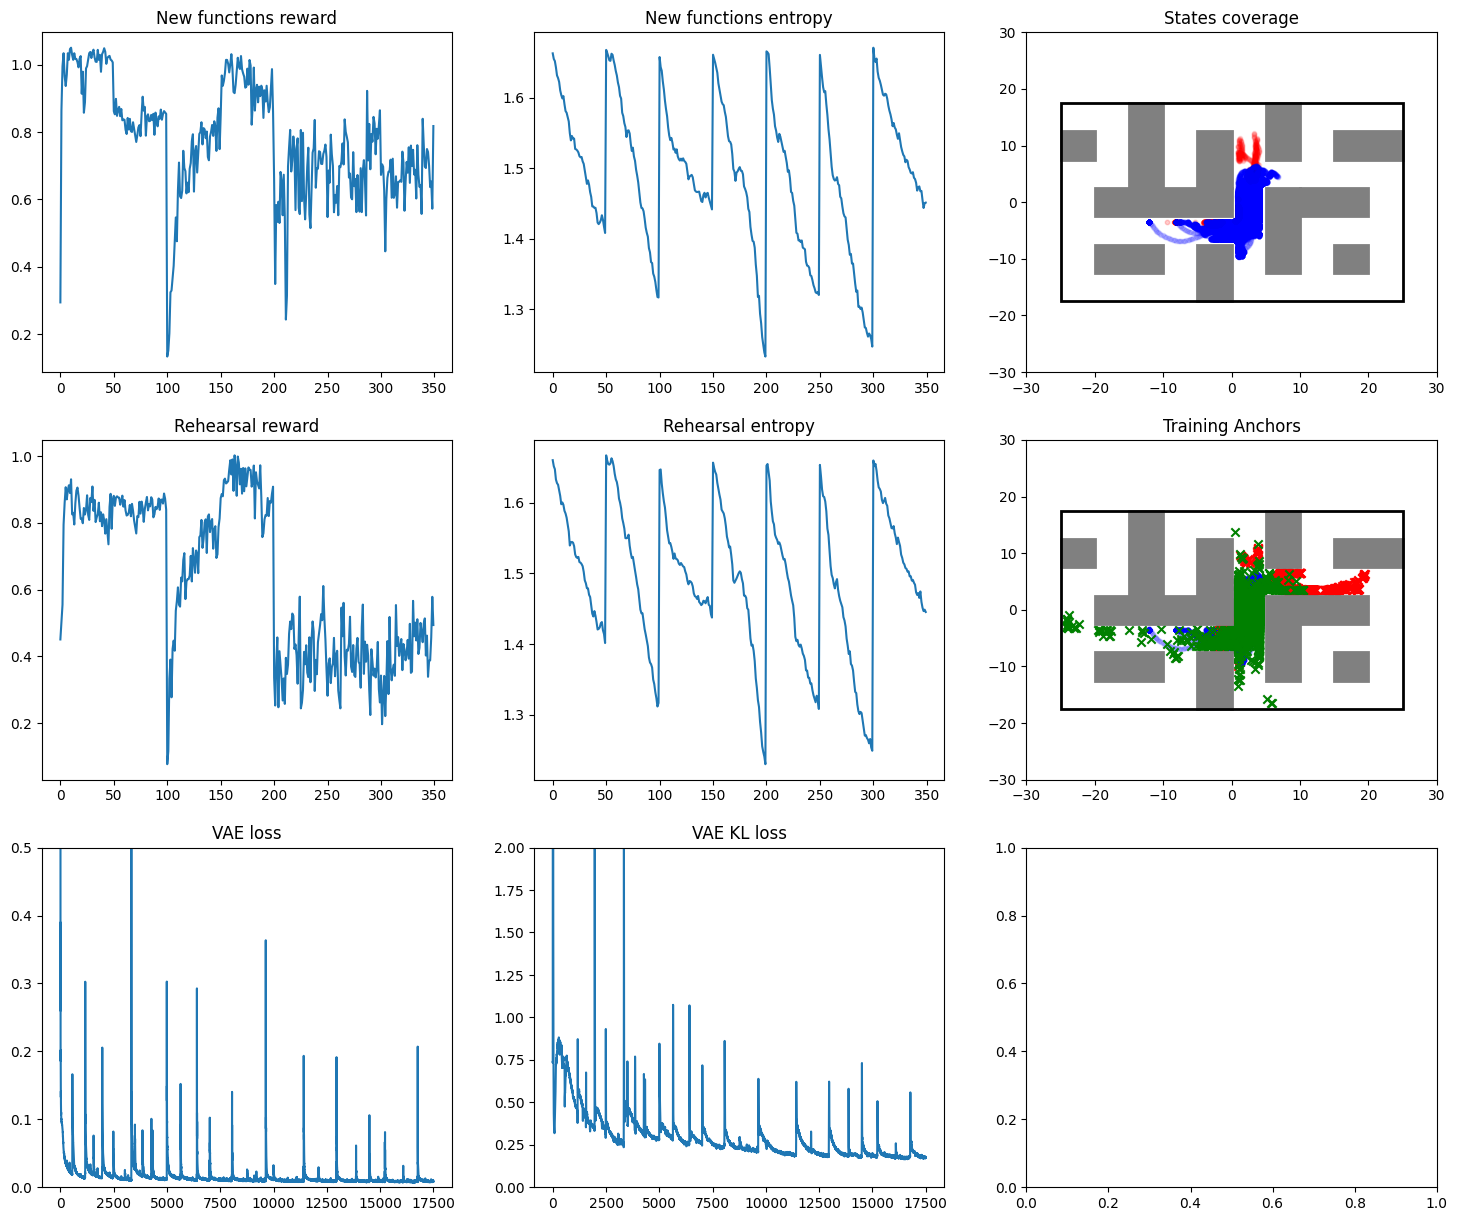

VAE training...


VAE training:   0%|          | 0/2500 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [154]:
for epoch in tqdm(range(1000)):
    
    ##### Explore new states using random actions ##################################################################
    from_prior = True if (reward_generator.new_states_buffer is None) else False
    print(f'Getting new states... from_prior={from_prior}')
    
    if from_prior == False:
        S = reward_generator.new_states_buffer
        reward_generator.new_states_buffer = torch.concat((reward_generator.new_states_buffer, reward_generator.states_buffer), dim=1)
    
    trajectory, random_states, get_new_states_info = get_new_states(
        5,
        env, model, reward_generator, 
        num_policy_steps=EPISODE_LENGTH, 
        num_random_steps=NUM_RANDOM_STEPS, 
        from_prior=from_prior
    )
    parcoured_states = trajectory['states'][..., :2].reshape(-1, 2)
    
    if from_prior == False:
        reward_generator.new_states_buffer = S
    
    
    
    new = random_states[:, :, :2].reshape(-1, 2)
    
    if reward_generator.states_buffer is not None:
        old = reward_generator.states_buffer.reshape(-1, 2)
    else:
        old = trajectory['states'][..., :2].reshape(-1, 2)
        
    filtered_new, filtering_info = filter_only_new_states(new, old, steps=1000)
    filtered_new = filtered_new.unsqueeze(0) # shape == (1, num_states, obs_len)
    
    # reward_generator.update_states_buffer    (random_states[..., :2])
    # reward_generator.update_new_states_buffer(random_states[:, -50:, :2])
    # reward_generator.update_new_states_buffer(filtered_new)
    
    if reward_generator.states_buffer is None:
        reward_generator.update_states_buffer(trajectory['states'][..., :2].reshape(1, -1, 2))
    else:
        reward_generator.update_states_buffer(reward_generator.new_states_buffer)
        
        
    reward_generator.new_states_buffer = filtered_new
    # reward_generator.update_new_states_buffer(filtered_new)
    
    
    plot_logs()

    
    
    ##### train the VAE: ###########################################################################################
    
    S = reward_generator.new_states_buffer
    reward_generator.new_states_buffer = torch.concat((reward_generator.new_states_buffer, reward_generator.states_buffer), dim=1)
    
    print('VAE training...')
    for _ in tqdm(range(2500), desc='VAE training', leave=False):
        vae_loss_dict = reward_generator.train_step_VAE(
            batch_size=512,
            min_num_anchors=MIN_NUM_ANCHORS,
            max_num_anchors=MAX_NUM_ANCHORS,
            num_states=16,
            non_anchor_coef=0.1,
            from_new_states=True
        )
        vae_loss.append(vae_loss_dict['loss'])
        vae_kl_loss.append(vae_loss_dict['kl_loss'])  
    
    reward_generator.new_states_buffer = S
          
    plot_logs()


    # ##### Estimate the emperical means and std to train the policy: ################################################
    # print('Mean and std estimation...')
    # empericial_mean, empericial_std = reward_generator.estimate_mean_std(steps=1000)    
    
    
    
    ##### Train the policy on new states (Exploration) #############################################################
    print('Policy training on new states...')
    
    model.action_var.data = torch.full((model.action_dim,), model.action_std**2, requires_grad=True, device=device)

    anchors_list, rehearsal_anchors_list = [], []
    for _ in tqdm(range(50), desc='Policy training', leave=False):
        avg_reward_1, entropy_1, info = train_on_new_states(env, model, optimizer, reward_generator, num_policy_steps=EPISODE_LENGTH)
        anchors_list.append(info['anchors'])
        rewards_list_1.append(avg_reward_1)
        entropies_1.append(entropy_1)
        
        avg_reward_2, entropy_2, info = policy_rehearsal(env, model, optimizer, reward_generator, num_policy_steps=EPISODE_LENGTH)
        rehearsal_anchors_list.append(info['anchors'])
        rewards_list_2.append(avg_reward_2)
        entropies_2.append(entropy_2)
        
    plot_logs()
    
    
    

    states_buffer_history.append((reward_generator.states_buffer, reward_generator.new_states_buffer, filtered_new))
 

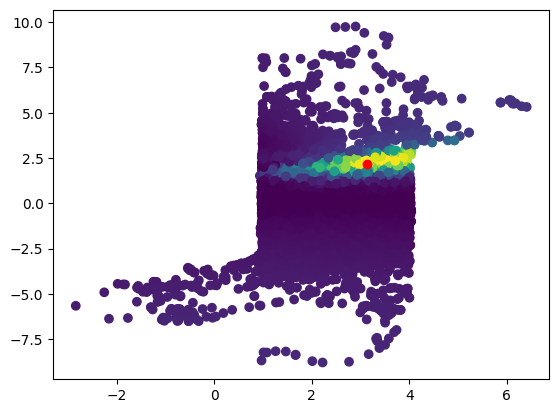

In [150]:
S = reward_generator.new_states_buffer
reward_generator.new_states_buffer = torch.concat((reward_generator.new_states_buffer, reward_generator.states_buffer), dim=1)

reward_generator.visualize(1, from_new_states=True)

reward_generator.new_states_buffer = S

In [ ]:
trajectory, random_states, get_new_states_info = get_new_states(
    5,
    env, model, reward_generator, 
    num_policy_steps=EPISODE_LENGTH, 
    num_random_steps=NUM_RANDOM_STEPS, 
    from_prior=False
)

Get new states:   0%|          | 0/5 [00:00<?, ?it/s]

tensor(-0.0486)


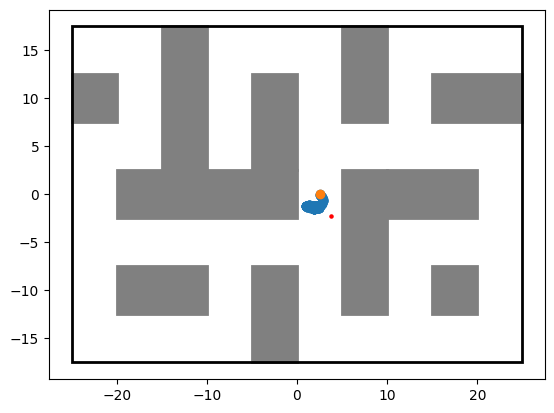

In [163]:
x = trajectory['states'].reshape(-1, EPISODE_LENGTH, 4)
y = random_states
z = get_new_states_info['anchors']
w = reward_generator.new_states_buffer.reshape(1, -1, 2)

i = 5

print(trajectory['rewards'].reshape(-1, EPISODE_LENGTH)[i, -1])


# plt.scatter(x[:, :, 0], x[:, :, 1])
# plt.scatter(y[:, :, 0], y[:, :, 1])

fig, ax = plt.subplots(1, 1)
ax.scatter(x[i, :, 0], x[i, :, 1])
ax.scatter(x[i, 0, 0], x[i, 0, 1])
# ax.scatter(w[i, :, 0], w[i, :, 1], c='yellow')
ax.scatter(z[i, :, 0], z[i, :, 1], c='red', s=5)

add_largest_maze_walls(ax)
# ax.set_xlim([-3, 3])
# ax.set_ylim([-3, 3])
plt.show()

In [ ]:
# torch.save(reward_generator.fre_network.state_dict(), 'models/online_fre_network_3.pth')
# torch.save(model.state_dict(), 'models/online_ppo_model_3.pth')

In [ ]:
# exp_id = 'test'
# os.makedirs(f'figures/exp_{exp_id}', exist_ok=True)
# for i in tqdm(range(len(states_buffer_history))):
#     plt.figure(figsize=(5, 5))
#     plt.scatter(states_buffer_history[i][1][..., 0], states_buffer_history[i][1][..., 1], s=10, c='red')
#     plt.scatter(states_buffer_history[i][0][..., 0], states_buffer_history[i][0][..., 1], s=10, alpha=0.1)
#     plt.scatter(states_buffer_history[i][2][..., 0], states_buffer_history[i][2][..., 1], s=10, alpha=0.1, c='yellow')
#     plt.xlim([-3, 3])
#     plt.ylim([-3, 3])
#     plt.savefig(f"figures/exp_{exp_id}/frame_{i}.png")
#     plt.close()

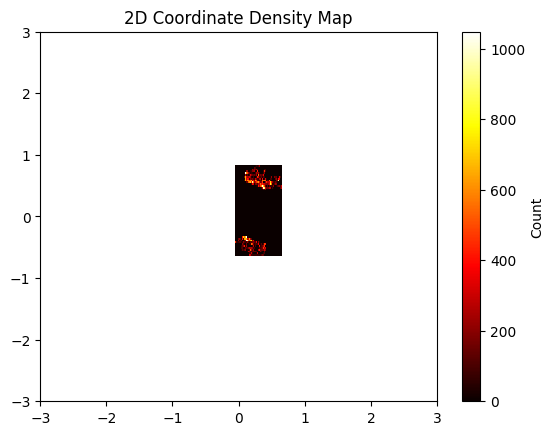

In [ ]:
# x = anchors['anchors'][:, 0, :]
x = reward_generator.new_states_buffer.reshape(-1, 2)
r = torch.randint(0, x.shape[0], (100_000,))
x = x[r]

num_bins = 50 # or choose based on desired resolution
heatmap, xedges, yedges = np.histogram2d(x[:, 0], x[:, 1], bins=num_bins)

# Plot the heatmap
plt.imshow(heatmap.T, origin='lower', 
           extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
           cmap='hot', interpolation='nearest', aspect='auto')
plt.colorbar(label='Count')
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.title('2D Coordinate Density Map')
plt.show()

In [ ]:
_ = reward_generator.estimate_mean_std(10000)

  0%|          | 0/1000 [00:00<?, ?it/s]

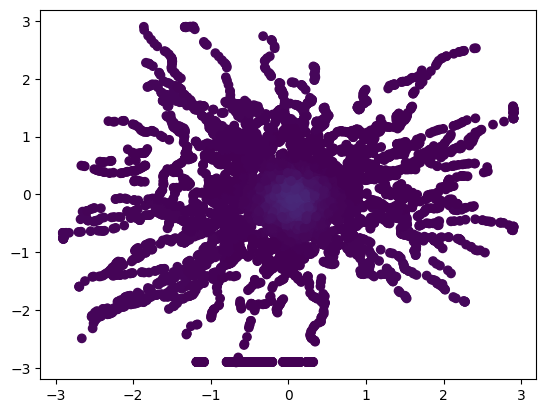

In [ ]:
(_, _), (all_states, _) = reward_generator.get_training_data(
    batch_size=1, 
    min_num_anchors=1, 
    max_num_anchors=1,
    num_states=10000,
    from_new_states=True
)
all_states = all_states.to(device)


r = []
for _ in tqdm(range(1000)):
    w = reward_generator.emperical_mean  + torch.normal(0, 1, reward_generator.emperical_mean.shape, device=device) * reward_generator.emperical_std
    # w = torch.normal(0, 1, emperical_mean.shape, device=device)
    
    w = w.unsqueeze(0)

    with torch.no_grad():
        rewards_pred = reward_generator.fre_network.get_reward_pred(w, all_states)
        
    r.append(rewards_pred.flatten().cpu())
    
avg_reward = torch.stack(r).mean(dim=0)
plt.scatter(all_states[0, :, 0].cpu(), all_states[0, :, 1].cpu(), c=avg_reward.detach().cpu(), vmin=0, vmax=1)

In [ ]:
avg_reward.min(), avg_reward.max()

(tensor(-0.0057), tensor(0.1194))

In [ ]:
anchors = []
a, b = 1.5, 2.25
x_coords = [-a + 2*a/3*n for n in range(4)]
y_coords = [-b + 2*b/3*n for n in range(4)]
for x1 in x_coords:
    for x2 in y_coords:
        anchors.append([x2, x1])
anchors = torch.tensor(anchors, device=device, dtype=torch.float32).unsqueeze(1)
pad_mask = torch.full((16, 1), fill_value=False, device=device)

In [ ]:
# eval_z, _ = reward_generator.get_z_from_anchors(anchors, pad_mask)
eval_z, anchors = reward_generator.get_z_from_random_anchors(eval_num_envs, min_num_anchors=MIN_NUM_ANCHORS, max_num_anchors=MAX_NUM_ANCHORS)
# eval_z, _ = reward_generator.get_z_from_prior(eval_num_envs)

trajectories = []
for _ in tqdm(range(1)):
    trajectories.append(collect_trajectories(eval_env, eval_z, model, n_steps=EPISODE_LENGTH, reward_generator=reward_generator))

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/16 [00:00<?, ?it/s]

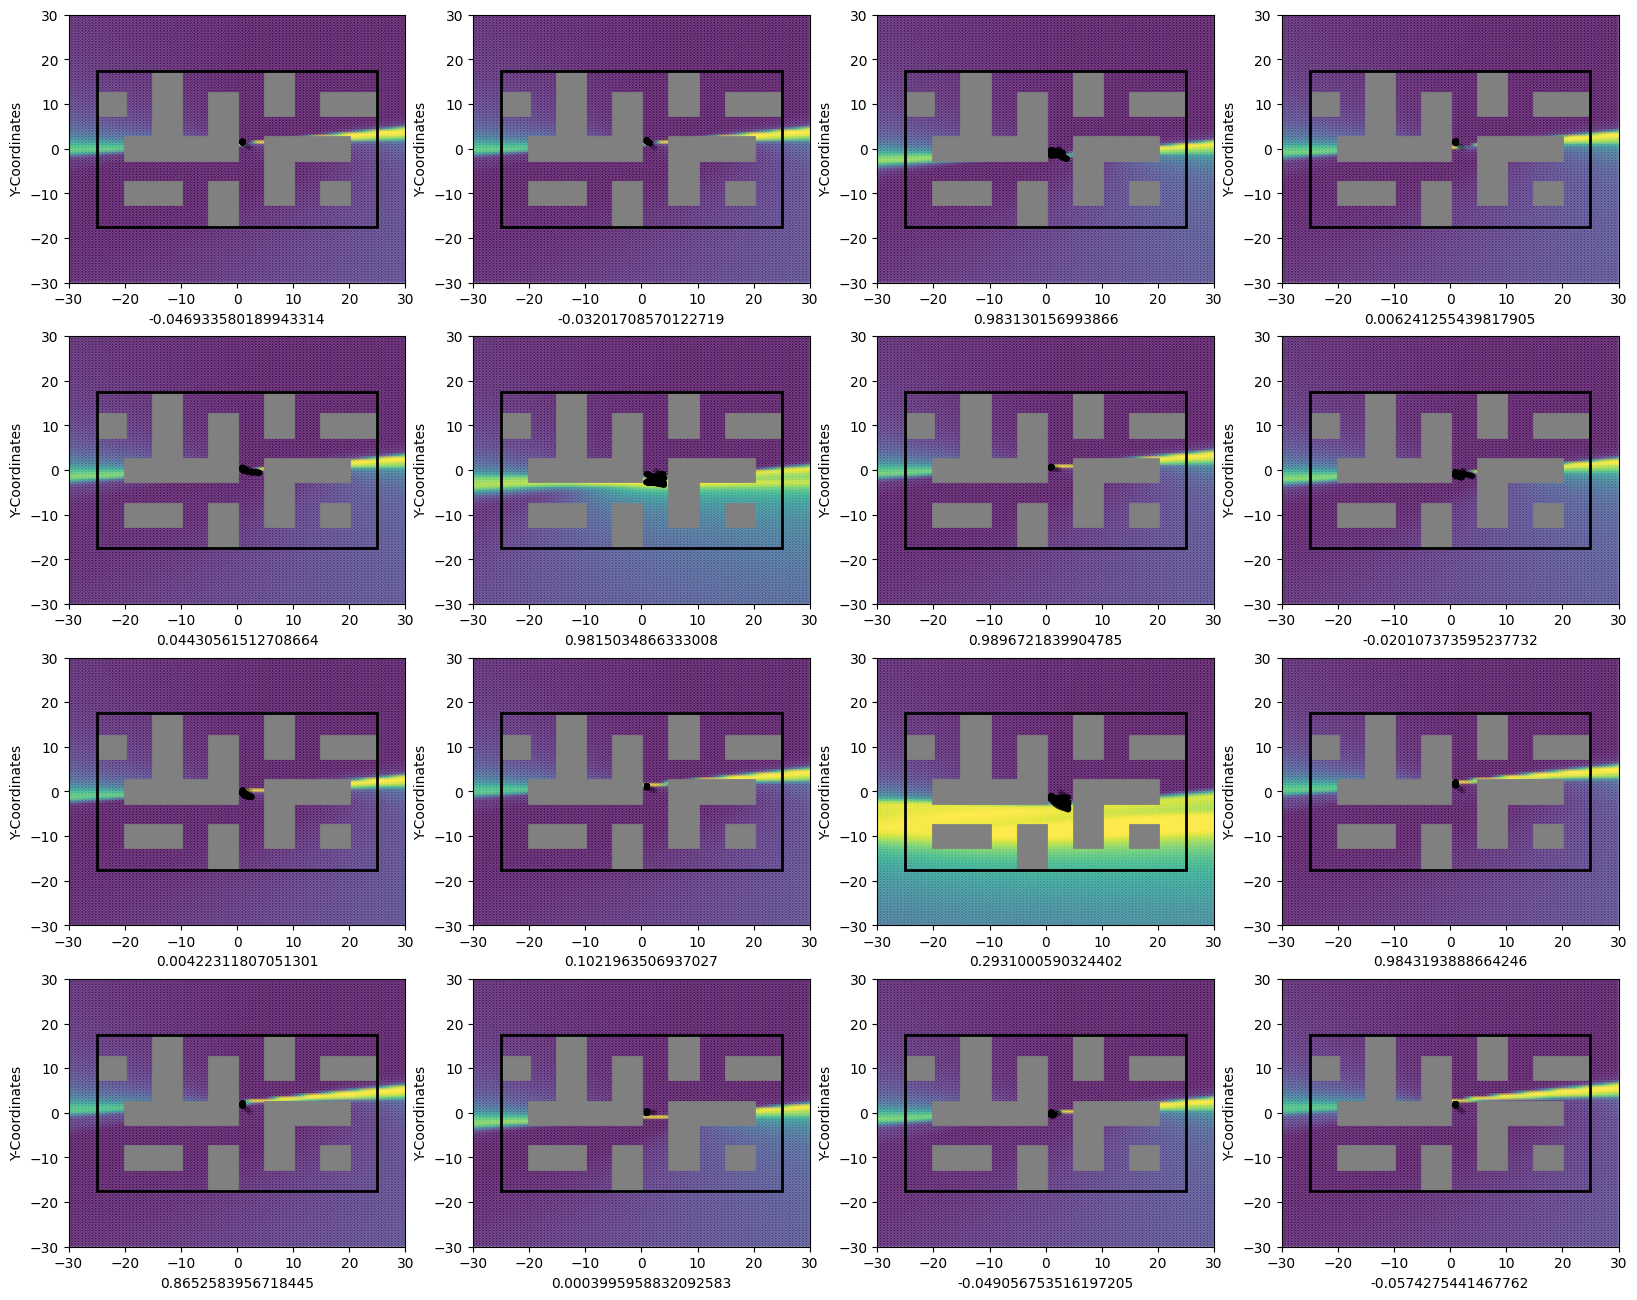

In [ ]:
s = 100
# x1_vals = np.linspace(-0.25, 0.25, s) * STATE_SCALE
# x2_vals = np.linspace(-0.175, 0.175, s) * STATE_SCALE

x1_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE
x2_vals = np.linspace(-0.3, 0.3, s) * STATE_SCALE

X1, X2 = np.meshgrid(x1_vals, x2_vals)
state_x12 = np.column_stack((X1.ravel(), X2.ravel()))
# print(X1.shape, X2.shape)

state = torch.zeros((s*s, 4), dtype=torch.float32)
state[:, :2] = torch.tensor(state_x12)
state[:, 2:] = torch.rand((s*s, 2)) * 0.1 - 0.05
state = state.to(device)

coods = reward_generator.new_states_buffer.reshape(-1, 2).to(device)

fig, axs = plt.subplots(4, 4, figsize=(20, 16))
axs = axs.flatten()

for i in tqdm(range(len(eval_z))):
    zi = eval_z[i].unsqueeze(0).repeat(state.shape[0], 1)
    with torch.no_grad():
        r = reward_generator.get_reward(state[..., :2], zi).cpu()
    
    
    # axs[i].scatter(state[:, 0].cpu(), state[:, 1].cpu(), c=r, alpha=0.3, s=20)
    # axs[i].scatter(coods[:, 0].cpu(), coods[:, 1].cpu(), c='red', alpha=0.3, s=20)
    axs[i].pcolormesh(X1, X2, r.reshape(X1.shape), cmap='viridis', shading='gouraud', alpha=0.5, vmin=0, vmax=1)
    # axs[i].scatter(anchors[i, 0, 0].cpu(), anchors[i, 0, 1].cpu(), c='brown', marker='X')
    
    for j in range(len(trajectories)):
        trajectory, _ = trajectories[j]
        coords = trajectory['states'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1), :2]
        r = trajectory['rewards'][EPISODE_LENGTH*i:EPISODE_LENGTH*(i+1)][-10:].mean()
        axs[i].scatter(coords[:, 0], coords[:, 1], alpha=np.linspace(0.0, 1, len(coords)), s=10, c='black')
        # axs[i].scatter(
        #     reward_generator.new_states_buffer.reshape(-1, 2)[:, 0], 
        #     reward_generator.new_states_buffer.reshape(-1, 2)[:, 1],
        #     s=5, c='red'
        # )
        axs[i].set_xlabel("X-Coordinates")  # Change this to your appropriate label
        axs[i].set_xlabel(f"{r}")
        axs[i].set_ylabel("Y-Coordinates")
        # axs[i].set_xlim([-0.1, 0.1])
        # axs[i].set_xlim([-0.1, 0.1])
    add_largest_maze_walls(axs[i])

plt.show()